In [1]:
%load_ext autoreload
%autoreload 2

# Imports

In [2]:
import numpy as np
from echofit.echofit import EchoFit

/Users/david/Library/Caches/pypoetry/virtualenvs/echofit-W-NSutmR-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Create an echofit instance

In [3]:
fit = EchoFit(M_BH=1e8)


# Data Ingestion

In [4]:
fit.add_lightcurve_csv("../data/uv.csv", wavelength=2000.0)
fit.add_lightcurve_csv("../data/optical.csv", wavelength=5000.0)

# Plot raw light curves

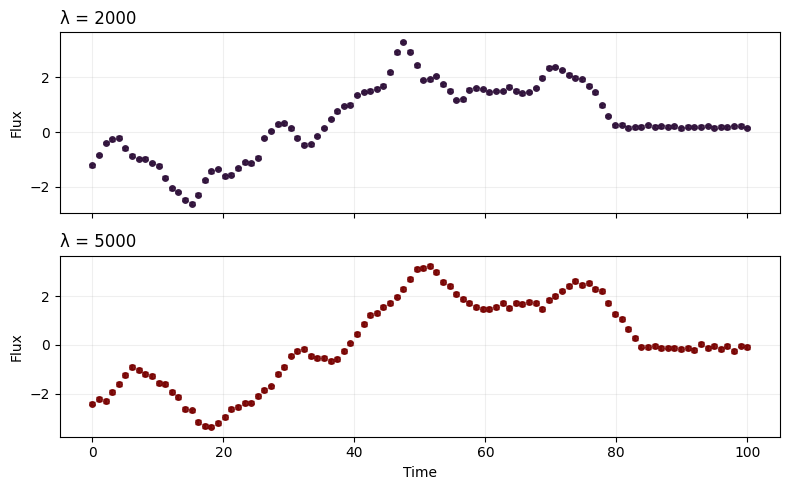

In [5]:
fit.plot_raw_lightcurve_data()

# Run

In [6]:
fit.fit(num_warmup=10, num_samples=20, fixed_params={'inclination':0.0,'log_sigma':0.0})

sample: 100%|██████████| 30/30 [00:35<00:00,  1.19s/it, 1023 steps of size 5.44e-03. acc. prob=0.93]


# Convergence Diagnostics

In [7]:
samples = fit.mcmc.get_samples()

for k in samples:
    print(k, np.mean(samples[k]), np.std(samples[k]))

C_0 -0.16275524 0.43703803
C_1 -0.45829582 0.4347753
S_0 -0.94281256 2.3349965
S_1 -6.27853 3.8873324
log_mdot -0.11333572 0.865367
log_tau_drw 3.7903564 0.22017026
loglike -3150.8594 3.665679


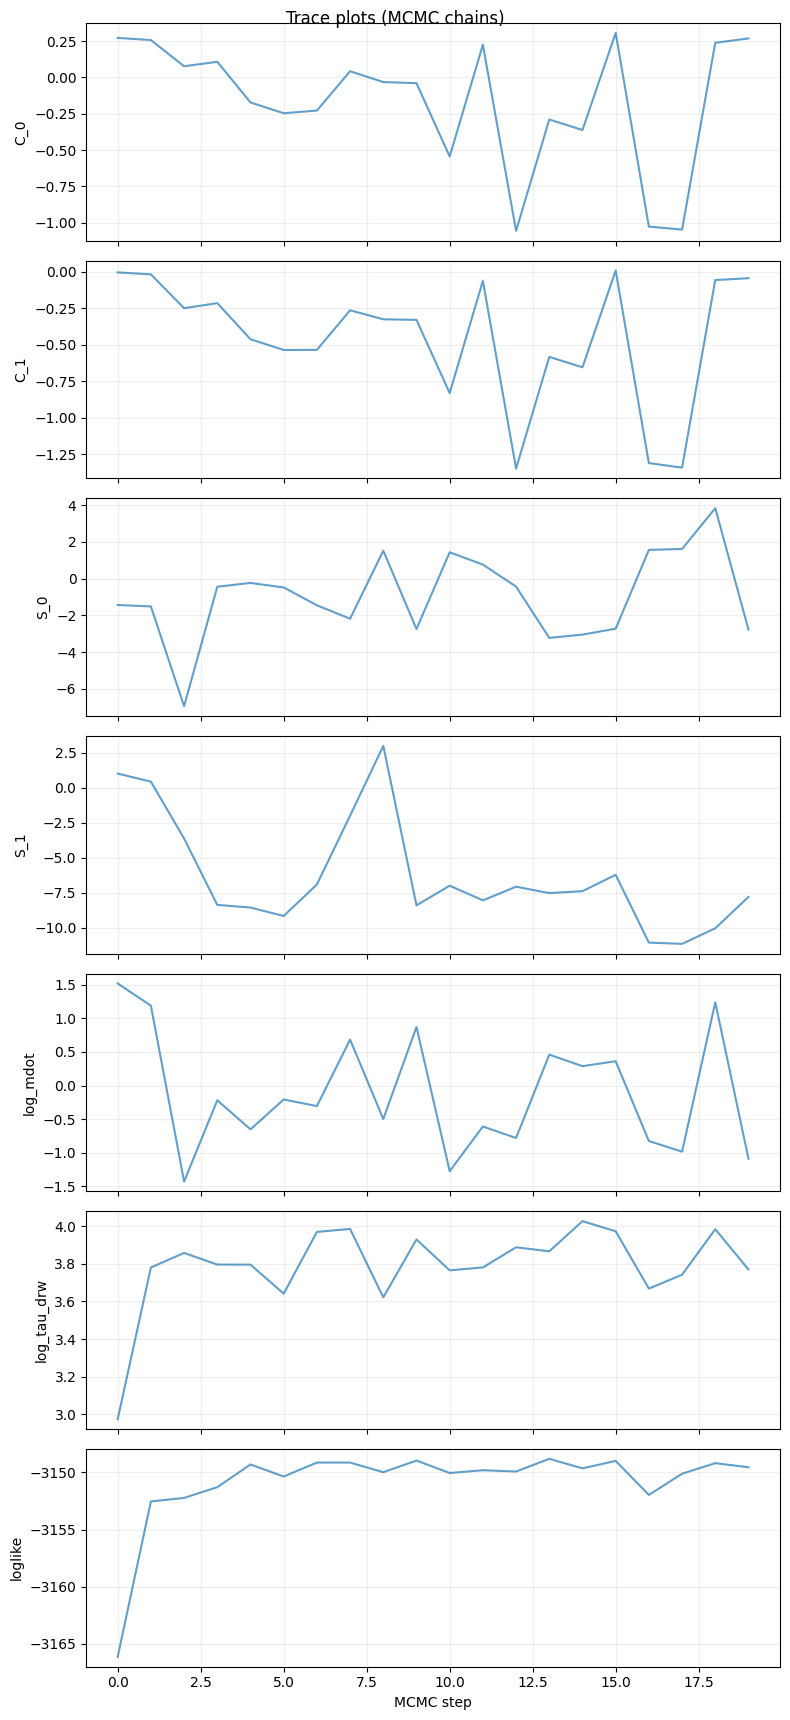

In [8]:
#fit.plot_trace()
#fit.summary()
fit.plot_mcmc_diagnostics()


# Posterior Dstributions

In [9]:
#fit.plot_posterior()

# Light curve fits

In [10]:
fit.fixed_params

{'inclination': 0.0, 'log_sigma': 0.0}

In [11]:
fit.mcmc.get_samples()

{'C_0': Array([ 0.27119994,  0.2564362 ,  0.07646718,  0.10695086, -0.17262003,
        -0.24660464, -0.228392  ,  0.04214244, -0.03222015, -0.04010859,
        -0.5438585 ,  0.22446682, -1.0556896 , -0.28954977, -0.36181805,
         0.30572048, -1.0261841 , -1.0468664 ,  0.23747021,  0.26795304],      dtype=float32),
 'C_1': Array([-0.00494372, -0.01824353, -0.24990699, -0.21518607, -0.4624471 ,
        -0.5359162 , -0.53525215, -0.26430157, -0.32583225, -0.32974792,
        -0.83070296, -0.06242385, -1.3476226 , -0.5831164 , -0.6545707 ,
         0.00778566, -1.310319  , -1.3412887 , -0.05733164, -0.04454806],      dtype=float32),
 'S_0': Array([-1.4325514 , -1.5102035 , -6.9364457 , -0.4386798 , -0.23418844,
        -0.47913596, -1.4476676 , -2.178988  ,  1.5194588 , -2.7382438 ,
         1.4327308 ,  0.7654828 , -0.43280244, -3.222305  , -3.0437796 ,
        -2.7201488 ,  1.5631732 ,  1.6142468 ,  3.830336  , -2.7665381 ],      dtype=float32),
 'S_1': Array([  1.0269203,   0.44513

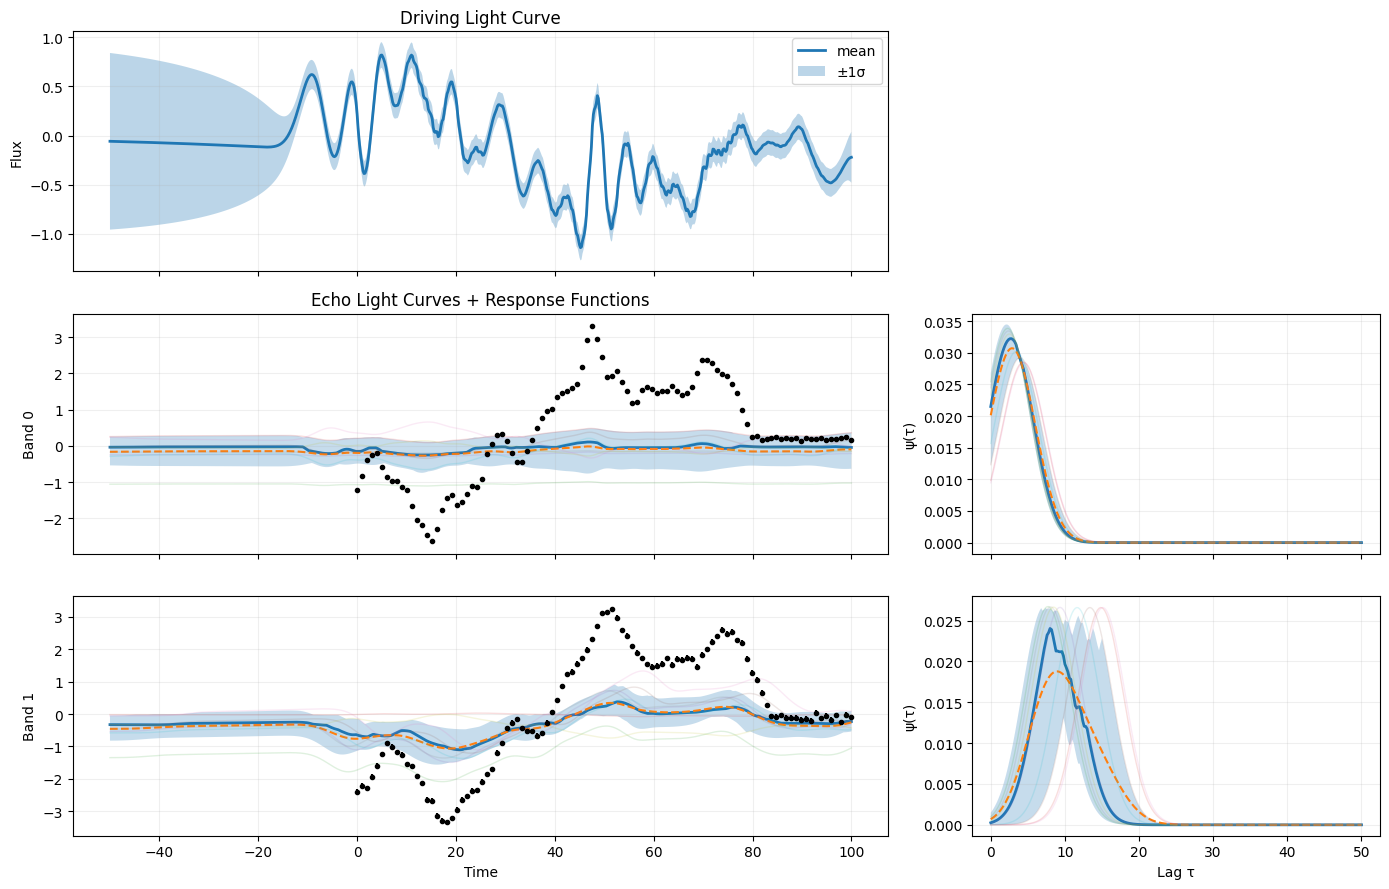

In [12]:
fit.plot_lightcurve_fits()

# Plot power spectrum of driver and BOF

KeyError: "Parameter 'log_sigma' not found in samples or fixed_params"

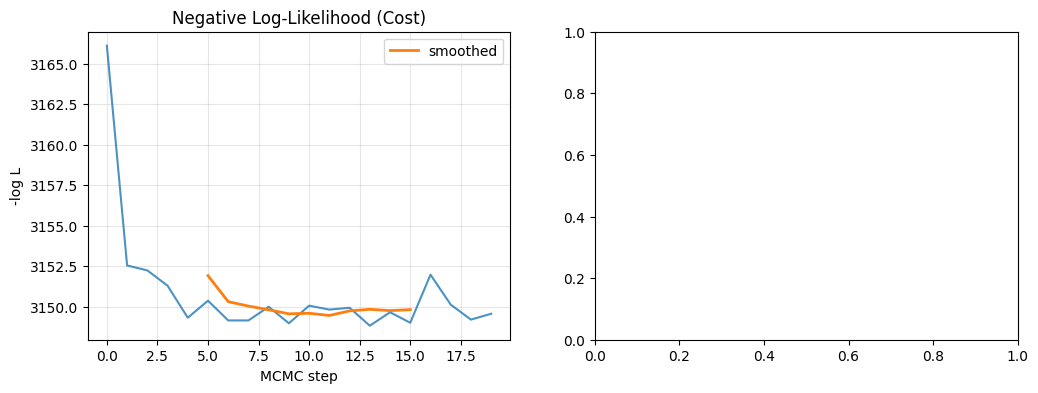

In [13]:
fit.plot_extended_diagnostics()

# Appendix

## Test response function

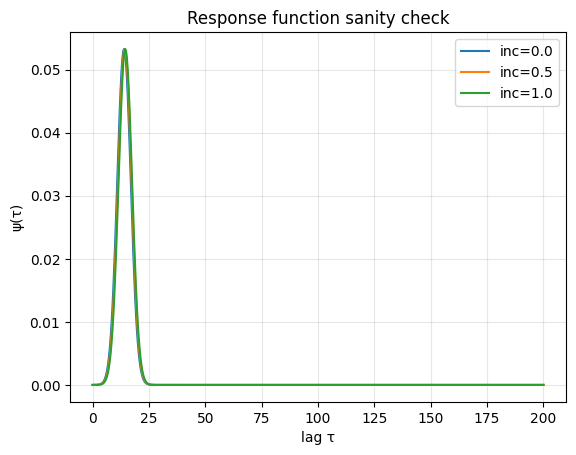

mu = 13.956125
sigma = 4.1868377
skew = 0.7615941559557649
tau range = 0.0 200.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from echofit.forward_model import build_response_function, lag_scaling

tau_grid = np.linspace(0, 200, 500)

M_BH = 1e8  # fixed mass

log_mdot = 1.0
wavelength = 5000.0

for inc in [0.0, 0.5, 1.0]:

    psi = build_response_function(
        tau_grid,
        log_mdot,
        wavelength,
        inc,
        M_BH,
    )

    plt.plot(tau_grid, psi, label=f"inc={inc}")

plt.xlabel("lag τ")
plt.ylabel("ψ(τ)")
plt.title("Response function sanity check")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

mu = lag_scaling(log_mdot, wavelength, M_BH)

sigma = 0.3 * mu
skew = np.tanh(inc)

print("mu =", mu)
print("sigma =", sigma)
print("skew =", skew)
print("tau range =", tau_grid.min(), tau_grid.max())